In [ ]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPool2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# 1. Khai báo đường dẫn và xử lý dữ liệu
train_dir = '/content/drive/MyDrive/nhận diện các loại bánh (1)' # Đổi đường dẫn tới thư mục 10 loại bánh
img_width, img_height = 280, 280
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1/255,
    shear_range=0.2,
    zoom_range=0.2,
    height_shift_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

# 2. Xây dựng Custom CNN (Đúng chuẩn yêu cầu của thầy, không dùng pretrained model)
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(33, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Dùng Dropout để chống overfitting theo lời khuyên của thầy
    Dense(10, activation='softmax') # CHÚ Ý: 10 loại bánh
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

# 3. Tiến hành Training
epochs = 30
history = model.fit(train_generator, epochs=epochs)
from keras.callbacks import ModelCheckpoint

# 1. Tạo "Phao cứu sinh": Tự động lưu lại file vào Drive sau mỗi vòng học nếu AI thông minh hơn
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/bakery_checkpoint_antoan.keras', # Lưu thẳng vào Drive
    monitor='accuracy',   # Theo dõi độ chính xác
    save_best_only=True,  # CHỈ LƯU khi vòng hiện tại tốt hơn vòng trước đó
    verbose=1
)

# 2. Gắn phao cứu sinh vào lúc Train (thêm tham số callbacks)
print("\n--- Bắt đầu Train (Có Auto-save) ---")
epochs = 30
history = model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[checkpoint] # <--- GẮN VÀO ĐÂY
)

# Chạy xong 30 vòng thì lưu chốt hạ bản cuối cùng
model.save('/content/drive/MyDrive/bakery_checkout_model_nhomHTT.keras')


Found 3940 images belonging to 10 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 278, 278, 33)   │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 139, 139, 33)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 137, 137, 64)   │        19,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 68, 68, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 66, 66, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 33, 33, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 139392)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    17,842,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,937,446 (68.43 MB)

 Trainable params: 17,937,446 (68.43 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
 17/124 ━━━━━━━━━━━━━━━━━━━━ 24:33 14s/step - accuracy: 0.1024 - loss: 4.1769

KeyboardInterrupt: 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
Đã nhận diện là bánh croissant nhưng chưa có trong bảng giá!


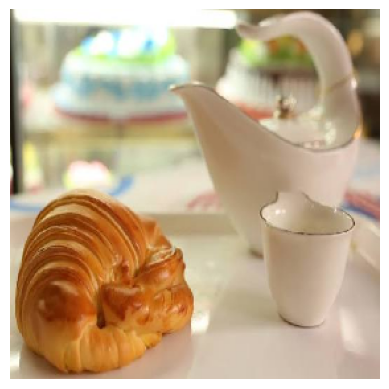

In [ ]:
from keras.models import load_model
from keras.utils import load_img
import numpy as np
import cv2
import matplotlib.pyplot as plt

model.save('/content/drive/MyDrive/bakery_checkout_model_nhomHTT.keras')

# 2. Bảng giá cập nhật theo Cửa hàng 3ITECH
menu_prices = {
    "Egg_Tart": 21000,
    "Croissant": 30000,
    "Cookies_Dua": 23000,
    "Cha_Bong_Cay": 27000,
    "Patechaud": 30000,
    "Banh_Mi_Dua_Luoi": 15000,
    "Banh_Da_Lon": 23000,
    "Banh_Mi_Bo": 18000,
    "Muffin_Viet_Quat": 25000,
    "Banh_Chuoi_Nuong": 19000
}

# Tên hiển thị tiếng Việt có dấu cho hóa đơn đẹp mắt hơn
display_names = {
    "Egg_Tart": "Egg Tart",
    "Croissant": "Croissant",
    "Cookies_Dua": "Cookies dừa",
    "Cha_Bong_Cay": "Chà bông cây",
    "Patechaud": "Patechaud",
    "Banh_Mi_Dua_Luoi": "Bánh mì dừa lưới",
    "Banh_Da_Lon": "Bánh da lợn",
    "Banh_Mi_Bo": "Bánh mì bơ (Cua lớn)",
    "Muffin_Viet_Quat": "Muffin Việt Quất",
    "Banh_Chuoi_Nuong": "Bánh chuối nướng"
}

# 3. Đưa ảnh qua "máy quét"
path = "/content/cua.jpg" # Đường dẫn ảnh test
img = load_img(path, target_size=(280, 280))
plt.imshow(img)
plt.axis('off')

img_arr = np.array(img) / 255.0
img_arr = img_arr.reshape(1, 280, 280, 3)

# 4. Mô hình dự đoán
prediction = np.argmax(model.predict(img_arr))
class_labels = {v:k for k, v in train_generator.class_indices.items()}
predicted_cake_code = class_labels[prediction]

# 5. Xuất hóa đơn
if predicted_cake_code in menu_prices:
    price = menu_prices[predicted_cake_code]
    cake_name = display_names.get(predicted_cake_code, predicted_cake_code)

    print("="*40)
    print("   HÓA ĐƠN TỰ ĐỘNG - CỬA HÀNG 3ITECH")
    print("="*40)
    print(f"Sản phẩm nhận diện: {cake_name}")
    print(f"Đơn giá:            {price:,} VND")
    print("="*40)
    print("Cảm ơn quý khách đã mua sắm!")
else:
    print(f"Đã nhận diện là {predicted_cake_code} nhưng chưa có trong bảng giá!")

In [ ]:
!pip install segment_anything

In [ ]:
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install opencv-python pycocotools matplotlib

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-x68mh0n2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-x68mh0n2
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

--2026-06-21 00:33:52--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.33, 13.249.182.62, 13.249.182.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2564550879 (2.4G) [binary/octet-stream]
Saving to: ‘sam_vit_h_4b8939.pth’

sam_vit_h_4b8939.pt 100%[===================>]   2.39G   129MB/s    in 24s     

2026-06-21 00:34:15 (103 MB/s) - ‘sam_vit_h_4b8939.pth’ saved [2564550879/2564550879]



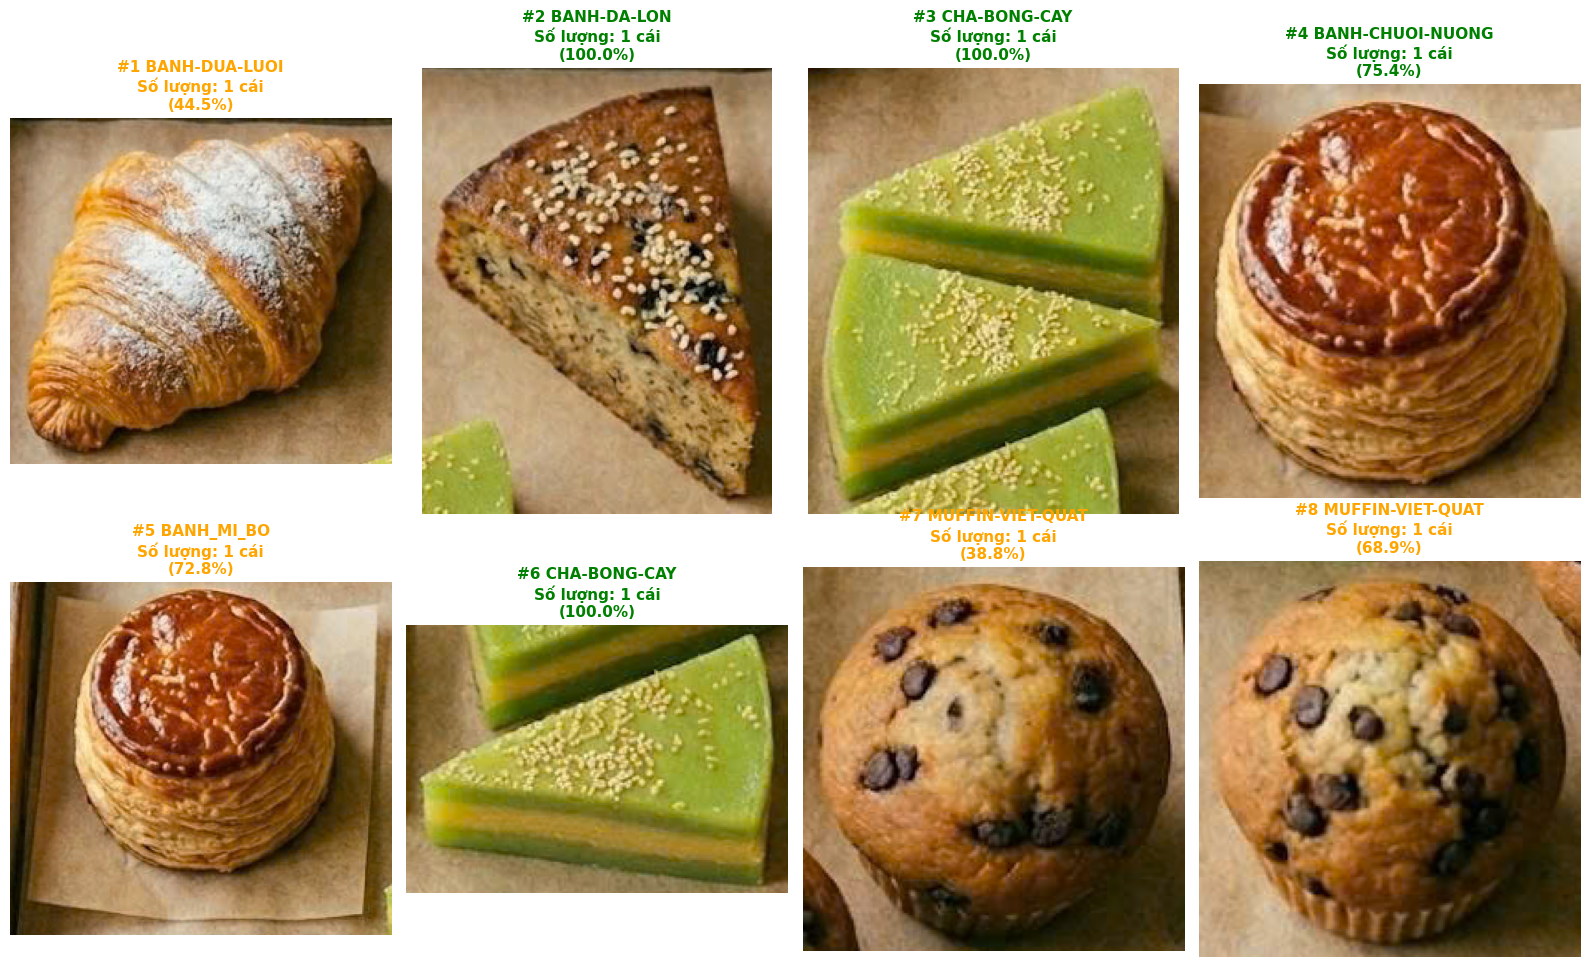


           HÓA ĐƠN TỔNG KẾT KHAY BÁNH (8 CÁI)          
STT  | Tên loại bánh        | Số lượng | Đơn giá    | Thành tiền
-------------------------------------------------------
1    | banh-chuoi-nuong     | 1        | 19,000đ    | 19,000 đ
2    | banh-da-lon          | 1        | 23,000đ    | 23,000 đ
3    | banh-dua-luoi        | 1        | 15,000đ    | 15,000 đ
4    | banh_mi_bo           | 1        | 18,000đ    | 18,000 đ
5    | cha-bong-cay         | 2        | 27,000đ    | 54,000 đ
6    | muffin-viet-quat     | 2        | 25,000đ    | 50,000 đ
-------------------------------------------------------
 TỔNG TIỀN CẦN THANH TOÁN: 179,000 ĐỒNG


In [ ]:
import os
import cv2
import numpy as np
import torch
import tensorflow as tf
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# XÓA DÒNG model.save Ở ĐÂY RỒI NHÉ

CLASS_NAMES = [
    'banh-chuoi-nuong', 'banh-da-lon', 'banh-dua-luoi', 'banh_mi_bo', 'cha-bong-cay',
    'cookies_dua', 'croissant', 'eggtart', 'muffin-viet-quat', 'patechaud'
]

PRICE_DICT = {
    'banh-chuoi-nuong': 19000,
    'banh-da-lon': 23000,
    'banh-dua-luoi': 15000,
    'banh_mi_bo': 18000,
    'cha-bong-cay': 27000,
    'cookies_dua': 23000,
    'croissant': 30000,
    'eggtart': 21000,
    'muffin-viet-quat': 25000,
    'patechaud': 30000
}

STANDARD_CAKE_AREA = 22000
IMAGE_PATH = '/content/khay bánh.jpg'
# SỬA LẠI ĐƯỜNG DẪN TRỎ VÀO DRIVE CHO ĐÚNG
CNN_MODEL_PATH = '/content/drive/MyDrive/bakery_checkout_model_nhomHTT.keras'

device = "cuda" if torch.cuda.is_available() else "cpu"
sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(
    model=sam, points_per_side=16, pred_iou_thresh=0.93, stability_score_thresh=0.96, crop_n_layers=0, min_mask_region_area=15000
)

# Load model CNN
cnn_model = tf.keras.models.load_model(CNN_MODEL_PATH)

if not os.path.exists(IMAGE_PATH):
    print(f"Không tìm thấy file ảnh tại: {IMAGE_PATH}")
else:
    image = cv2.imread(IMAGE_PATH)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 1. Chạy SAM để tìm mask
    raw_masks = mask_generator.generate(image_rgb)
    raw_masks = sorted(raw_masks, key=lambda x: x['area'], reverse=True)

    clean_masks = []
    img_height, img_width, _ = image.shape
    max_area_allow = img_height * img_width * 0.15

    # Lọc mask rác
    for mask_data in raw_masks:
        area = mask_data['area']
        x, y, w, h = [int(v) for v in mask_data['bbox']]
        aspect_ratio = w / float(h)

        if aspect_ratio > 2.2 or aspect_ratio < 0.45:
            continue
        if area < 15000 or area > max_area_allow:
            continue

        is_duplicate = False
        current_mask = mask_data['segmentation']
        for saved_mask in clean_masks:
            intersection = np.logical_and(current_mask, saved_mask['segmentation'])
            if np.sum(intersection) / np.sum(current_mask) > 0.4:
                is_duplicate = True
                break
        if not is_duplicate:
            clean_masks.append(mask_data)

    clean_masks = sorted(clean_masks, key=lambda x: (x['bbox'][1], x['bbox'][0]))

    temp_images = []
    cnn_input_batch = []
    mask_areas = []

    for mask_data in clean_masks:
        x, y, w, h = [int(v) for v in mask_data['bbox']]
        area = mask_data['area']

        pad_w = int(w * 0.05)
        pad_h = int(h * 0.05)
        x1 = max(0, x - pad_w)
        y1 = max(0, y - pad_h)
        x2 = min(img_width, x + w + pad_w)
        y2 = min(img_height, y + h + pad_h)

        cropped_natural = image_rgb[y1:y2, x1:x2]

        # SỬA LỖI 3: KÍCH THƯỚC VỀ LẠI 280x280
        img_for_cnn = cv2.resize(cropped_natural, (280, 280))
        img_array = tf.keras.preprocessing.image.img_to_array(img_for_cnn)

        # SỬA LỖI 4: CHUẨN HÓA DỮ LIỆU CHIA 255
        img_array = img_array / 255.0

        temp_images.append(cropped_natural)
        cnn_input_batch.append(img_array)
        mask_areas.append(area)

    total_detected_blocks = len(temp_images)

    if total_detected_blocks > 0:
        cnn_input_batch = np.array(cnn_input_batch)
        all_predictions = cnn_model.predict(cnn_input_batch, batch_size=32, verbose=0)

        bill_summary = {name: 0 for name in CLASS_NAMES}
        final_results = []
        total_items_counted = 0

        for idx in range(total_detected_blocks):
            score = all_predictions[idx]
            class_idx = np.argmax(score)
            predicted_label = CLASS_NAMES[class_idx]
            actual_area = mask_areas[idx]

            # SỬA LỖI 5: CĂN LỀ LẠI CHO ĐÚNG CHUẨN PYTHON
            if predicted_label == 'banh-da-lon':
                calculated_count = int(np.round(actual_area / STANDARD_CAKE_AREA))
                cake_count = max(1, calculated_count)
            else:
                cake_count = 1

            bill_summary[predicted_label] += cake_count
            total_items_counted += cake_count
            cake_price = PRICE_DICT[predicted_label]

            final_results.append({
                'image': temp_images[idx],
                'label': predicted_label,
                'count': cake_count,
                'price': cake_price,
                'confidence': score[class_idx] * 100
            })

        cols = 4
        rows = (total_detected_blocks + cols - 1) // cols
        plt.figure(figsize=(16, 5 * rows))

        for idx, res in enumerate(final_results):
            plt.subplot(rows, cols, idx + 1)
            plt.imshow(res['image'])

            title_text = f"#{idx+1} {res['label'].upper()}\nSố lượng: {res['count']} cái\n({res['confidence']:.1f}%)"
            color = 'green' if res['confidence'] > 75 else 'orange'

            plt.title(title_text, fontsize=11, fontweight='bold', color=color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()

        print("\n" + "="*55)
        print(f"HÓA ĐƠN TỔNG KẾT KHAY BÁNH ({total_items_counted} CÁI)".center(55))
        print("="*55)
        print(f"{'STT'.ljust(4)} | {'Tên loại bánh'.ljust(20)} | {'Số lượng'.ljust(8)} | {'Đơn giá'.ljust(10)} | {'Thành tiền'}")
        print("-"*55)

        total_money = 0
        stt = 1
        for name, count in bill_summary.items():
            if count > 0:
                unit_price = PRICE_DICT[name]
                sub_total = count * unit_price
                total_money += sub_total

                print(f"{str(stt).ljust(4)} | {name.ljust(20)} | {str(count).ljust(8)} | {f'{unit_price:,}đ'.ljust(10)} | {sub_total:,} đ")
                stt += 1

        print("-"*55)
        print(f" TỔNG TIỀN CẦN THANH TOÁN: {total_money:,} ĐỒNG")
        print("="*55)
    else:
        print("Hệ thống không quét được bánh hợp lệ. Hãy kiểm tra lại ảnh đầu vào!")